# **Import Library**

In [244]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# **Load the Dataset**

In [245]:
df=pd.read_csv('/content/global_house_purchase_dataset.csv')
df

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,Germany,Berlin,Villa,Fully-Furnished,685,203328,1968,1,3,...,78330,104050,15,17670,99278,0.01,8,4,5,1
199996,199997,China,Shenzhen,Townhouse,Unfurnished,3818,1454627,1977,5,7,...,25400,1175297,20,2865,279330,0.34,7,10,9,1
199997,199998,Japan,Kyoto,Villa,Semi-Furnished,3603,1619147,1990,2,4,...,28220,743049,30,5595,876098,0.17,5,3,9,0
199998,199999,South Africa,Johannesburg,Apartment,Unfurnished,1706,306165,2010,0,4,...,12240,150774,15,16300,155391,0.11,6,10,6,0


In [246]:
df=df.drop(['property_id','garage','garden','customer_salary','monthly_expenses','connectivity_score','neighbourhood_rating','down_payment','loan_amount','crime_cases_reported','previous_owners','legal_cases_on_property'],axis=1)

In [247]:
df.head()

,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,rooms,bathrooms,loan_tenure_years,emi_to_income_ratio,satisfaction_score,decision
0,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,2,15,0.16,1,0
1,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,8,8,20,0.08,9,0
2,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,2,1,30,0.09,6,0
3,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,3,3,15,0.33,2,0
4,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,3,3,25,0.03,3,0


# **Understanding the Data**

In [248]:
df.info

<bound method DataFrame.info of              country            city property_type furnishing_status  \
0             France       Marseille     Farmhouse    Semi-Furnished   
1       South Africa       Cape Town     Apartment    Semi-Furnished   
2       South Africa    Johannesburg     Farmhouse    Semi-Furnished   
3            Germany       Frankfurt     Farmhouse    Semi-Furnished   
4       South Africa    Johannesburg     Townhouse   Fully-Furnished   
...              ...             ...           ...               ...   
199995       Germany          Berlin         Villa   Fully-Furnished   
199996         China        Shenzhen     Townhouse       Unfurnished   
199997         Japan           Kyoto         Villa    Semi-Furnished   
199998  South Africa    Johannesburg     Apartment       Unfurnished   
199999        Brazil  Rio de Janeiro     Apartment    Semi-Furnished   

        property_size_sqft    price  constructed_year  rooms  bathrooms  \
0                      991   412935              1989      6          2   
1                     1244   224538              1990      8          8   
2                     4152   745104              2019      2          1   
3                     3714  1110959              2008      3          3   
4                      531    99041              2007      3          3   
...                    ...      ...               ...    ...        ...   
199995                 685   203328              1968      3          2   
199996                3818  1454627              1977      7          5   
199997                3603  1619147              1990      4          4   
199998                1706   306165              2010      4          1   
199999                3652   732698              1986      1          1   

        loan_tenure_years  emi_to_income_ratio  satisfaction_score  decision  
0                      15                 0.16                   1         0  
1                      20                 0.08                   9         0  
2                      30                 0.09                   6         0  
3                      15                 0.33                   2         0  
4                      25                 0.03                   3         0  
...                   ...                  ...                 ...       ...  
199995                 15                 0.01                   8         1  
199996                 20                 0.34                   7         1  
199997                 30                 0.17                   5         0  
199998                 15                 0.11                   6         0  
199999                 30                 0.15                   6         0  

[200000 rows x 13 columns]>

In [249]:
df.isnull().sum()

,0
country,0
city,0
property_type,0
furnishing_status,0
property_size_sqft,0
price,0
constructed_year,0
rooms,0
bathrooms,0
loan_tenure_years,0


In [250]:
df.describe

<bound method NDFrame.describe of              country            city property_type furnishing_status  \
0             France       Marseille     Farmhouse    Semi-Furnished   
1       South Africa       Cape Town     Apartment    Semi-Furnished   
2       South Africa    Johannesburg     Farmhouse    Semi-Furnished   
3            Germany       Frankfurt     Farmhouse    Semi-Furnished   
4       South Africa    Johannesburg     Townhouse   Fully-Furnished   
...              ...             ...           ...               ...   
199995       Germany          Berlin         Villa   Fully-Furnished   
199996         China        Shenzhen     Townhouse       Unfurnished   
199997         Japan           Kyoto         Villa    Semi-Furnished   
199998  South Africa    Johannesburg     Apartment       Unfurnished   
199999        Brazil  Rio de Janeiro     Apartment    Semi-Furnished   

        property_size_sqft    price  constructed_year  rooms  bathrooms  \
0                      991   412935              1989      6          2   
1                     1244   224538              1990      8          8   
2                     4152   745104              2019      2          1   
3                     3714  1110959              2008      3          3   
4                      531    99041              2007      3          3   
...                    ...      ...               ...    ...        ...   
199995                 685   203328              1968      3          2   
199996                3818  1454627              1977      7          5   
199997                3603  1619147              1990      4          4   
199998                1706   306165              2010      4          1   
199999                3652   732698              1986      1          1   

        loan_tenure_years  emi_to_income_ratio  satisfaction_score  decision  
0                      15                 0.16                   1         0  
1                      20                 0.08                   9         0  
2                      30                 0.09                   6         0  
3                      15                 0.33                   2         0  
4                      25                 0.03                   3         0  
...                   ...                  ...                 ...       ...  
199995                 15                 0.01                   8         1  
199996                 20                 0.34                   7         1  
199997                 30                 0.17                   5         0  
199998                 15                 0.11                   6         0  
199999                 30                 0.15                   6         0  

[200000 rows x 13 columns]>

In [251]:
df.duplicated().sum()

np.int64(0)

In [252]:
df.shape

(200000, 13)

In [253]:
df['city'].value_counts()

,count
city,
Singapore,15278
São Paulo,7755
Johannesburg,7712
Cape Town,7689
Rio de Janeiro,7642
Dubai,7637
Abu Dhabi,7504
Marseille,5328
Beijing,5328


In [254]:
df['country'].value_counts()

,count
country,
France,15628
China,15536
Australia,15442
UK,15413
Germany,15408
South Africa,15401
Canada,15401
Brazil,15397
India,15357


In [255]:
df['property_type'].value_counts()

,count
property_type,
Farmhouse,33518
Apartment,33398
Townhouse,33395
Villa,33347
Independent House,33334
Studio,33008


In [256]:
df['furnishing_status'].value_counts()

,count
furnishing_status,
Fully-Furnished,66829
Semi-Furnished,66673
Unfurnished,66498


# **EDA**

<Axes: xlabel='property_type', ylabel='count'>

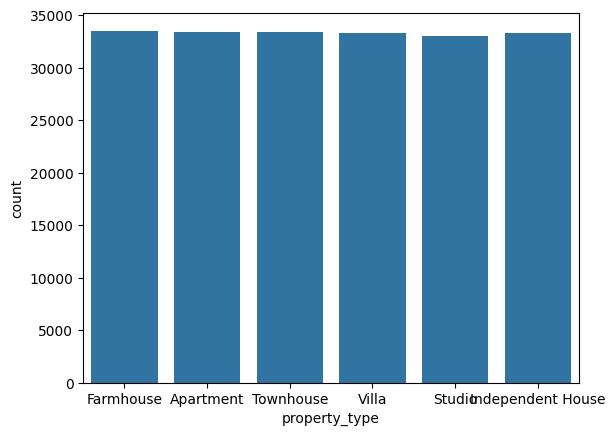

In [257]:
sns.countplot(x='property_type',data=df)

<Axes: xlabel='furnishing_status'>

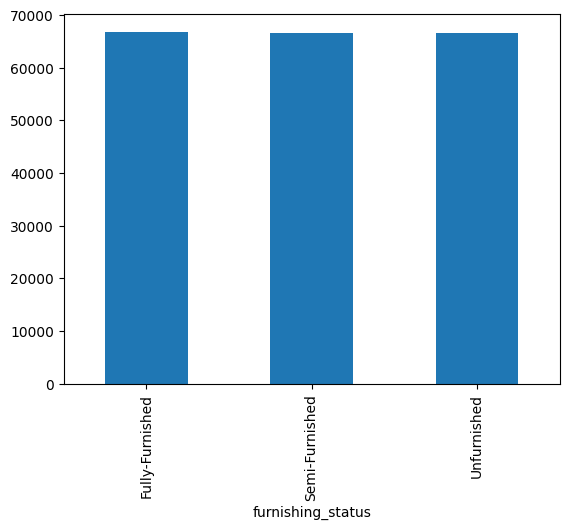

In [258]:
df['furnishing_status'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

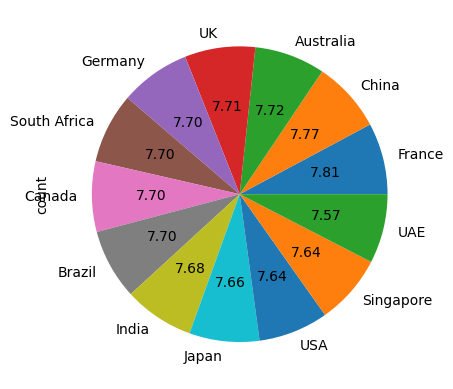

In [259]:
df['country'].value_counts().plot(kind = 'pie',autopct= '%.2f')

<Axes: ylabel='count'>

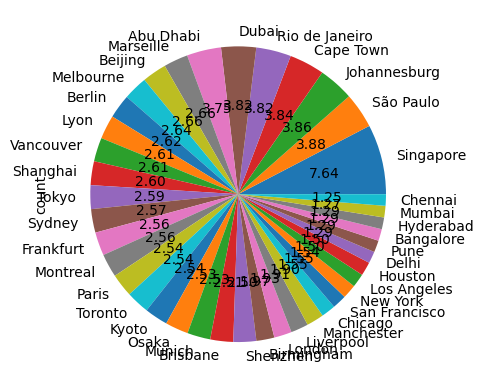

In [260]:
df['city'].value_counts().plot(kind = 'pie',autopct= '%.2f')

<Axes: xlabel='rooms', ylabel='bathrooms'>

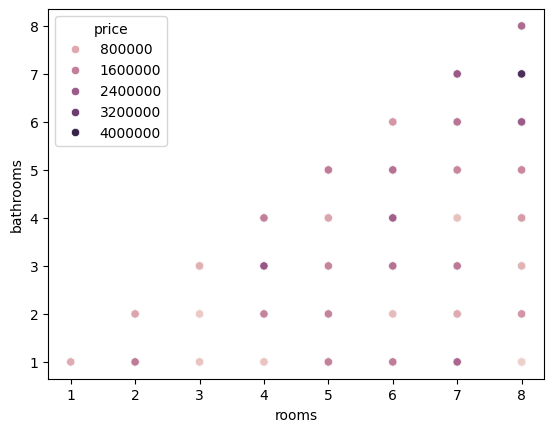

In [261]:
sns.scatterplot(x="rooms",y="bathrooms",hue="price",data= df )

<Axes: xlabel='rooms'>

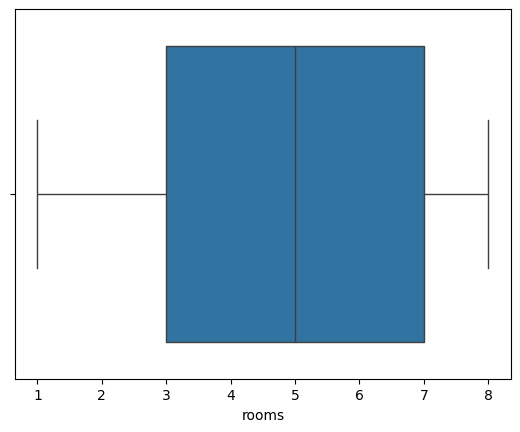

In [262]:
sns.boxplot(x='rooms',data=df)

<Axes: xlabel='rooms', ylabel='country'>

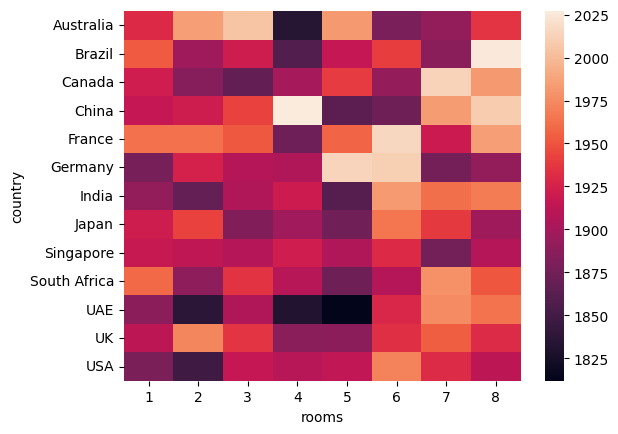

In [263]:
sns.heatmap(pd.crosstab(df["country"],df["rooms"]))

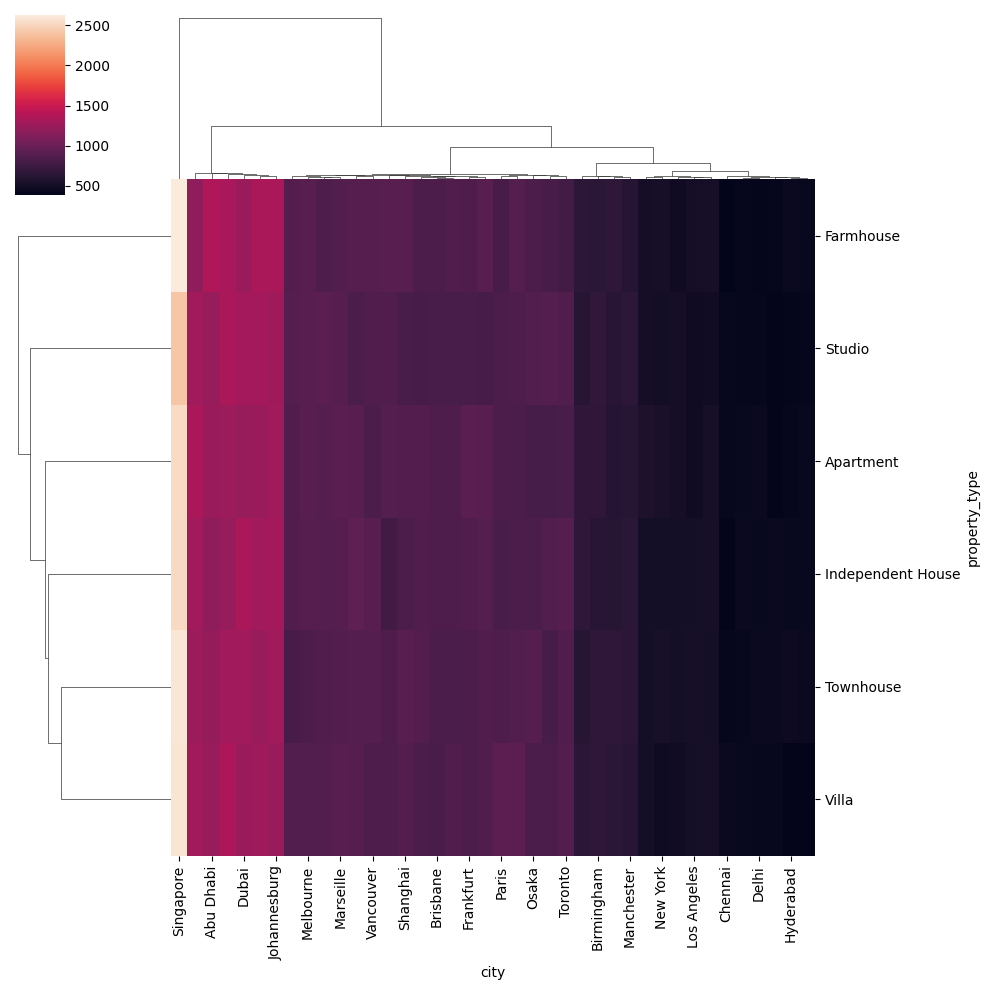

In [264]:
sns.clustermap(pd.crosstab(df["property_type"],df["city"]))

/tmp/ipykernel_7623/3769897815.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'],kde=True)


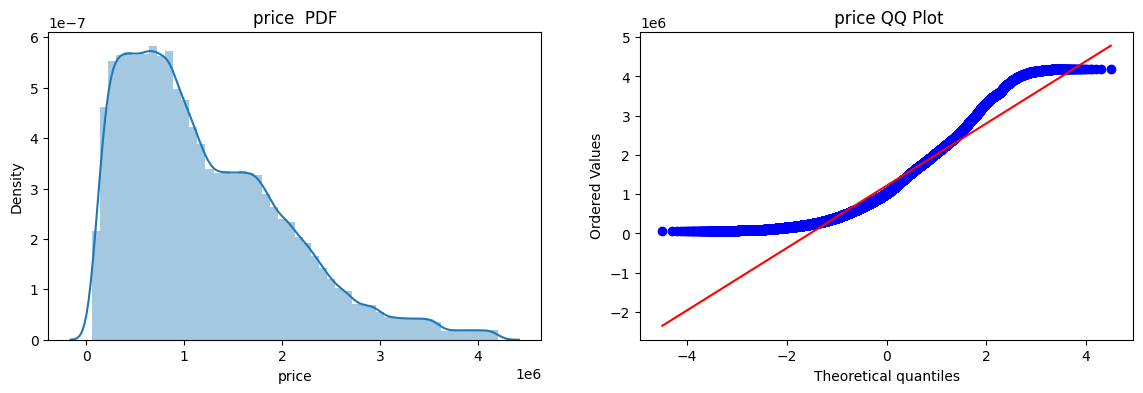

In [265]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['price'],kde=True)
plt.title('price  PDF')

plt.subplot(122)
stats.probplot(df['price'], dist="norm", plot=plt)
plt.title(' price QQ Plot')

plt.show()

/tmp/ipykernel_7623/3845746709.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rooms'],kde=True)


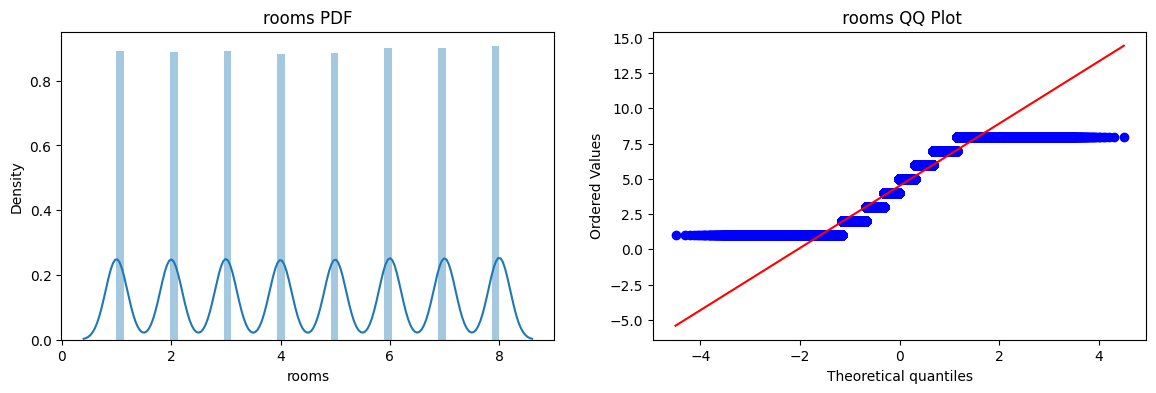

In [266]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['rooms'],kde=True)
plt.title('rooms PDF')

plt.subplot(122)
stats.probplot(df['rooms'], dist="norm", plot=plt)
plt.title(' rooms QQ Plot')

plt.show()

/tmp/ipykernel_7623/4123260169.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathrooms'],kde=True)


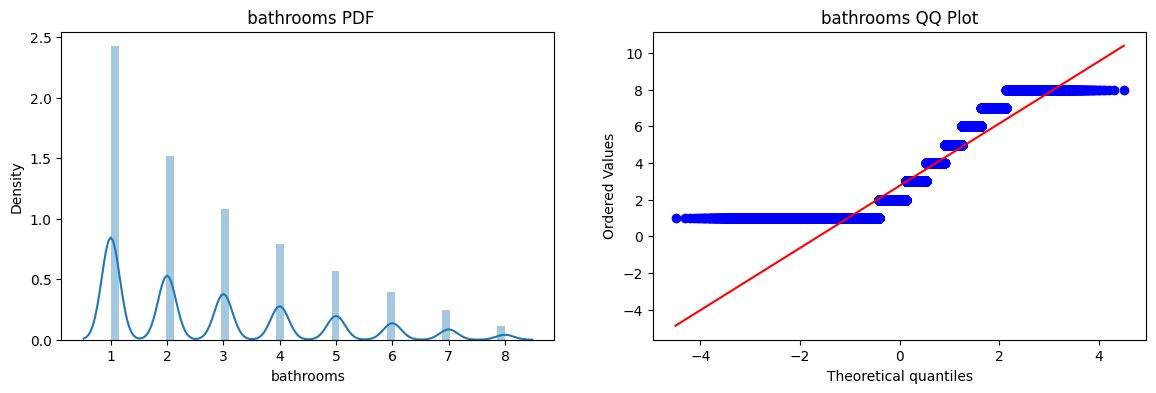

In [267]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['bathrooms'],kde=True)
plt.title(' bathrooms PDF')

plt.subplot(122)
stats.probplot(df['bathrooms'], dist="norm", plot=plt)
plt.title('bathrooms QQ Plot')

plt.show()

/tmp/ipykernel_7623/2568691259.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['property_size_sqft'],kde=True)


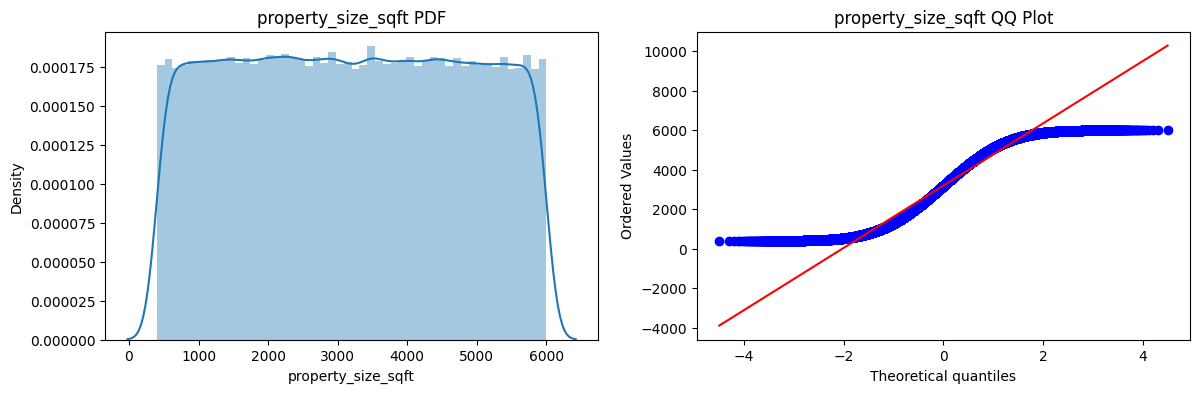

In [268]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['property_size_sqft'],kde=True)
plt.title('property_size_sqft PDF')

plt.subplot(122)
stats.probplot(df['property_size_sqft'], dist="norm", plot=plt)
plt.title('property_size_sqft QQ Plot')

plt.show()

/tmp/ipykernel_7623/1289788826.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['satisfaction_score'],kde=True)


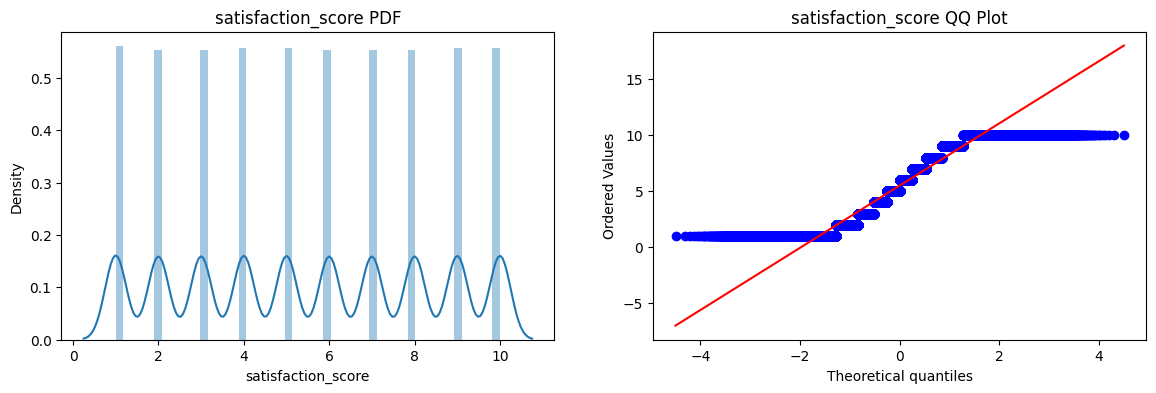

In [269]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['satisfaction_score'],kde=True)
plt.title('satisfaction_score PDF')

plt.subplot(122)
stats.probplot(df['satisfaction_score'], dist="norm", plot=plt)
plt.title('satisfaction_score QQ Plot')

plt.show()

# **test_train_split**

In [270]:
X=df.drop('decision',axis=1)
y=df['decision']

In [271]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# **Column Transformer**

In [272]:
preprocessor = ColumnTransformer(transformers=[
  ('OneHot',OneHotEncoder(drop='first', sparse_output=False),['property_type','furnishing_status','city','country']),
  ('Robust', RobustScaler(), ['property_size_sqft','price']),
  ('Standard', StandardScaler(), ['rooms','bathrooms','emi_to_income_ratio'])
],remainder='passthrough')

# **Applying Algorthim**

In [273]:
# RandomForestClassifier
pipeline_rf = Pipeline([
    ('prepro', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# **Fit **

In [274]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

pipeline_rf.fit(X_train, y_train_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prepro',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['property_type',
                                                   'furnishing_status', 'city',
                                                   'country']),
                                                 ('Robust', RobustScaler(),
                                                  ['property_size_sqft',
                                                   'price']),
                                                 ('Standard', StandardScaler(),
                                                  ['rooms', 'bathrooms',
                                                   'emi_to_income_ratio'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [275]:
rf_acc = pipeline_rf.score(X_test, y_test_encoded)

# **Accuracy score**

In [276]:
accuracy = pipeline_rf.score(X_test, y_test_encoded)
print(f"Random Forest Accuracy:     {accuracy:.4f}")

Random Forest Accuracy:     0.8710


# **Confusion Matrix**

In [277]:
# Use your actual test data and model predictions from the fitted Random Forest pipeline
y_pred = pipeline_rf.predict(X_test)

# Generate the report using your real encoded test labels
print(classification_report(y_test_encoded, y_pred, target_names=[str(c) for c in le.classes_]))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     30786
           1       0.68      0.85      0.75      9214

    accuracy                           0.87     40000
   macro avg       0.81      0.86      0.83     40000
weighted avg       0.89      0.87      0.88     40000



# **Import Pickle**

In [280]:
import pickle
pickle.dump(pipeline_rf,open('pipe.pkl','wb'))